# My spotify account analysis with Spotify API

In this project, I will use spotify API to get data about my most listened songs and artist and analyse it

**IMPORTANT NOTE**
Spotify policy prohibits training any AI model on spotify data so I will just perform an analysis without any machine learning

# Data collection and cleaning

In [ ]:
!pip install wikipedia

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=84e22e4ef4bb4c66095add3c1424b8711c9ed45714aa4490322bfdcd32347521
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia


In [132]:
import requests
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#import wikipedia as wp
from bs4 import BeautifulSoup
import re
from wordcloud import WordCloud

## Requesting data
If there are no ready files

In [ ]:
token = ''

In [ ]:
headers = {
    'Authorization': f'Bearer {token}'
}

params = {
    'time_range': 'short_term',
    'limit': '50',
}

tracks_short = requests.get('https://api.spotify.com/v1/me/top/tracks', params=params, headers=headers).json()

In [ ]:
params = {
    'time_range': 'medium_term',
    'limit': '50',
}

tracks_medium = requests.get('https://api.spotify.com/v1/me/top/tracks', params=params, headers=headers).json()

In [ ]:
params = {
    'time_range': 'long_term',
    'limit': '50',
}

tracks_long = requests.get('https://api.spotify.com/v1/me/top/tracks', params=params, headers=headers).json()

In [ ]:
params = {
    'time_range': 'long_term',
    'limit': '50',
}

artists_long = requests.get('https://api.spotify.com/v1/me/top/artists', params=params, headers=headers).json()

In [ ]:
params = {
    'time_range': 'medium_term',
    'limit': '50',
}

artists_medium = requests.get('https://api.spotify.com/v1/me/top/artists', params=params, headers=headers).json()

In [ ]:
params = {
    'time_range': 'short_term',
    'limit': '50',
}

artists_short = requests.get('https://api.spotify.com/v1/me/top/artists', params=params, headers=headers).json()

In [ ]:
with open('ashort.txt', 'w') as f:
  json.dump(artists_short, f, ensure_ascii=False)
with open('amed.txt', 'w') as f:
  json.dump(artists_medium, f, ensure_ascii=False)
with open('along.txt', 'w') as f:
  json.dump(artists_long, f, ensure_ascii=False)
with open('tshort.txt', 'w') as f:
  json.dump(tracks_short, f, ensure_ascii=False)
with open('tmed.txt', 'w') as f:
  json.dump(tracks_medium, f, ensure_ascii=False)
with open('tlong.txt', 'w') as f:
  json.dump(tracks_long, f, ensure_ascii=False)

In [ ]:
with open('tshort.txt', 'w') as f:
  json.dump(tracks_short, f, ensure_ascii=False)

## Loading ready json files
If there are ready json files

In [ ]:
with open('ashort.txt', 'r') as f:
  artists_short = json.load(f)
with open('amed.txt', 'r') as f:
  artists_medium = json.load(f)
with open('along.txt', 'r') as f:
  artists_long = json.load(f)
with open('tshort.txt', 'r') as f:
  tracks_short = json.load(f)
with open('tmed.txt', 'r') as f:
  tracks_medium = json.load(f)
with open('tlong.txt', 'r') as f:
  tracks_long = json.load(f)

## Creating database

Here I know that I can turn jsons dirrectly into Dataframe, nevertheless I need to modify and clean every attribute so it is quicker, more convienient for me and more readable to create dataframes through dictionaries

In [ ]:
artists_short = json.loads(json.dumps(artists_short['items']))
artists_medium = json.loads(json.dumps(artists_medium['items']))
artists_long = json.loads(json.dumps(artists_long['items']))
tracks_short = json.loads(json.dumps(tracks_short['items']))
tracks_medium = json.loads(json.dumps(tracks_medium['items']))
tracks_long = json.loads(json.dumps(tracks_long['items']))

In [ ]:
artists_dict = {"artist_id": [], "artist_name": []}
album_artist_dict = {"artist_id": [], "album_id":[]}
albums_dict = {"album_id":[], 'album_name':[], 'release_year':[], 'release_month':[]}
tracks_dict = {'track_id': [], 'track_name':[], 'album_id':[], 'explicit':[],'durations_ms':[]}
genres_dict = {'album_id': [], 'genre': []}

In [ ]:
headers = {'User-Agent': 'SpotifyAccountAnalysis/0.0 (https://github.com/WalkedKO/Data-Analysis-And-Machine-Learning-Projects/tree/main/MySpotifyAccountAnalysisWithAPI/SpotifyAPI; walkedko@gmail.com)'}

In [ ]:
def get_genres(text, genres):
  try:
    html = BeautifulSoup(text, 'html.parser')
    for items in html.find('table', class_ = 'infobox').find_all('tr'):
      data = items.find_all(['th', 'td'])
      if data[0].text.strip() in ("Genre", "Genres", "Gatunek", "Gatunki"):
        for genre in data[1].find_all('a'):
          if genre.text[0] != '[':
            genres.append(genre.text.lower())
  except:
    pass

In [ ]:
def create_track_obj(obj):
  new_dict = {'place':[], 'track_id':[]}
  for place, item in enumerate(obj):
    new_dict['place'].append(place)
    new_dict['track_id'].append(item['id'])

    artists = item['artists']
    album = item['album']

    tracks_dict['track_id'].append(item['id'])
    tracks_dict['track_name'].append(item['name'])
    tracks_dict['album_id'].append(album['id'])
    tracks_dict['explicit'].append(item['explicit'])
    tracks_dict['durations_ms'].append(item['duration_ms'])
    for artist in artists:
      artists_dict['artist_id'].append(artist['id'])
      artists_dict['artist_name'].append(artist['name'])
      album_artist_dict['artist_id'].append(artist['id'])
      album_artist_dict['album_id'].append(album['id'])

    albums_dict['album_id'].append(album['id'])
    albums_dict['album_name'].append(album['name'])
    albums_dict['release_year'].append(album['release_date'][:4])
    albums_dict['release_month'].append(album['release_date'][5:7])

    #get genres
    name = re.sub(r'\(.*?\)', '', album['name'])
    name = name.strip()
    name = name.replace(' ', '_')
    genres = []
    response = requests.get(f"https://en.wikipedia.org/wiki/{name}_(album)", headers=headers)
    if response.status_code == 200:
      get_genres(response.text, genres)
    else:
      response = requests.get(f"https://en.wikipedia.org/wiki/{name}", headers=headers)
      if response.status_code == 200:
        get_genres(response.text, genres)
      else:
        response = requests.get(f"https://pl.wikipedia.org/wiki/{name}", headers=headers)
        if response.status_code == 200:
          get_genres(response.text, genres)
        else:
          name = re.sub(r'\(.*?\)', '', artists[0]['name'])
          name = name.strip()
          name = name.replace(' ', '_')
          response = requests.get(f"https://en.wikipedia.org/wiki/{name}_(singer)", headers=headers)
          if response.status_code == 200:
            get_genres(response.text, genres)
          else:
            response = requests.get(f"https://en.wikipedia.org/wiki/{name}_(band)", headers=headers)
            if response.status_code == 200:
              get_genres(response.text, genres)
            else:
              response = requests.get(f"https://en.wikipedia.org/wiki/{name}", headers=headers)
              if response.status_code == 200:
                get_genres(response.text, genres)
              else:
                response = requests.get(f"https://en.wikipedia.org/wiki/{name}", headers=headers)
                if response.status_code == 200:
                  get_genres(response.text, genres)
                else:
                  response = requests.get(f"https://pl.wikipedia.org/wiki/{name}", headers=headers)
                  if response.status_code == 200:
                    get_genres(response.text, genres)
    for genre in genres:
      genres_dict['album_id'].append(album['id'])
      genres_dict['genre'].append(genre)
  return pd.DataFrame(new_dict).drop_duplicates()

In [ ]:
def create_artist_obj(obj):
  new_dict = {'place':[], 'artist_id':[]}
  for place, item in enumerate(obj):
    new_dict['place'].append(place)
    new_dict['artist_id'].append(item['id'])
    artists_dict['artist_id'].append(item['id'])
    artists_dict['artist_name'].append(item['name'])
  return pd.DataFrame(new_dict).drop_duplicates()

In [ ]:
tracks_short_df = create_track_obj(tracks_short)
print('a')
tracks_medium_df = create_track_obj(tracks_medium)
print('b')
tracks_long_df = create_track_obj(tracks_long)
artists_short_df = create_artist_obj(artists_short)
artists_medium_df = create_artist_obj(artists_medium)
artists_long_df = create_artist_obj(artists_long)
artists_df = pd.DataFrame(artists_dict).drop_duplicates()
albums_df = pd.DataFrame(albums_dict).drop_duplicates()
tracks_df = pd.DataFrame(tracks_dict).drop_duplicates()
album_artist_df = pd.DataFrame(album_artist_dict).drop_duplicates()
genres_df = pd.DataFrame(genres_dict).drop_duplicates()

a
b


Loading ready database from .csv (optional)

## Data export

In [ ]:
tracks_short_df.to_csv('tracks_short.csv', index=False)
tracks_medium_df.to_csv('tracks_medium.csv', index=False)
tracks_long_df.to_csv('tracks_long.csv', index=False)
artists_short_df.to_csv('artists_short.csv', index=False)
artists_medium_df.to_csv('artists_medium.csv', index=False)
artists_long_df.to_csv('artists_long.csv', index=False)
artists_df.to_csv('artists.csv', index=False)
albums_df.to_csv('albums.csv', index=False)
tracks_df.to_csv('tracks.csv', index=False)
album_artist_df.to_csv('album_artist.csv', index=False)
genres_df.to_csv('genres.csv', index=False)

## Data loading

In [3]:
tracks_short_df = pd.read_csv('tracks_short.csv')
tracks_medium_df = pd.read_csv('tracks_medium.csv')
tracks_long_df = pd.read_csv('tracks_long.csv')
artists_short_df = pd.read_csv('artists_short.csv')
artists_medium_df = pd.read_csv('artists_medium.csv')
artists_long_df = pd.read_csv('artists_long.csv')
artists_df = pd.read_csv('artists.csv')
albums_df = pd.read_csv('albums.csv')
tracks_df = pd.read_csv('tracks.csv')
album_artist_df = pd.read_csv('album_artist.csv')
genres_df = pd.read_csv('genres.csv')

# Data Description

For every track and artist ranking list there are two columns:
- place in ranking
- id (str)

In [4]:
tracks_long_df.head()

,place,track_id
0,0,348u3kyvdh35xgeCuXf7yk
1,1,5QBozbgRWIYDSriHCRTsXd
2,2,2OErSh4oVVAUll0vHxdr6p
3,3,0wae8KoprNjfrXWjYYHGy9
4,4,0ybMBs8mKdAP9WSnFTiZvs


In [5]:
artists_long_df.head()

,place,artist_id
0,0,0TMvoNR0AIJV138mHY6jdE
1,1,1aSxMhuvixZ8h9dK9jIDwL
2,2,57DlMWmbVIf2ssJ8QBpBau
3,3,3sntDD4Y2K97qvDq3GPqZ5
4,4,0qibngGI3EFCen6abY5hqY


artists_df contatins:
- artist_id (str)
- artist_name

In [6]:
artists_df.head()

,artist_id,artist_name
0,57DlMWmbVIf2ssJ8QBpBau,Toby Fox
1,1aSxMhuvixZ8h9dK9jIDwL,Kate Bush
2,7mv15aFhJmcqNEGeiYWWbt,Fabienne DelSol
3,0qibngGI3EFCen6abY5hqY,Pidżama Porno
4,7t0rwkOPGlDPEhaOcVtOt9,The Cranberries


albums_df conatins:
- album_id
- album_name
- release_year
- release_month

In [7]:
albums_df.head()

,album_id,album_name,release_year,release_month
0,7DAiPXN3HdbktwwFzQXqrZ,DELTARUNE Chapter 2 (Original Game Soundtrack),2021,9.0
1,5G5UwqPsxDKpxJLX4xsyuh,Hounds Of Love,1985,9.0
2,0KBFDO8qcY0zhybIESEQUt,Never for Ever (2018 Remaster),1980,9.0
3,5NKTuBLCYhN0OwqFiGdXd1,The Kick Inside,1978,2.0
4,2cRwYvvGigsHqk63ZGfuI2,The Dreaming (2018 Remaster),1982,9.0


album_artist_df describes authors of a given album because sometimes there are more than one artist that created the album, there are attributes:
- artist_id (foreign key referencing artist_id in artists_df)
- album_id (foreign key referencing album_id in albums_df)

In [8]:
album_artist_df.head()

,artist_id,album_id
0,57DlMWmbVIf2ssJ8QBpBau,7DAiPXN3HdbktwwFzQXqrZ
1,1aSxMhuvixZ8h9dK9jIDwL,5G5UwqPsxDKpxJLX4xsyuh
2,1aSxMhuvixZ8h9dK9jIDwL,0KBFDO8qcY0zhybIESEQUt
3,1aSxMhuvixZ8h9dK9jIDwL,5NKTuBLCYhN0OwqFiGdXd1
4,1aSxMhuvixZ8h9dK9jIDwL,2cRwYvvGigsHqk63ZGfuI2


tracks_df contains:
- track_id
- track_name
- album_id (foreign key referencing album_id in albums_df)
- explicit (boolean) tells if song is declared as explicit on spotify
- duration_ms (integer) song duration in miliseconds

In [9]:
tracks_df.head()

,track_id,track_name,album_id,explicit,durations_ms
0,2hpQl8ryv3IonCg9LiAtGT,BIG SHOT,7DAiPXN3HdbktwwFzQXqrZ,False,142285
1,1kGO54rUtSq3FQ74u5BGvm,Jig Of Life,5G5UwqPsxDKpxJLX4xsyuh,False,244306
2,3dSd4f3KMC3efgKlODlnfZ,Delius - 2018 Remaster,0KBFDO8qcY0zhybIESEQUt,False,171346
3,2LtaWqNRnCRBvONackei6O,Violin - 2018 Remaster,0KBFDO8qcY0zhybIESEQUt,False,195186
4,1PtXEYrahu8Vg2rhpJBoqt,Moving,5NKTuBLCYhN0OwqFiGdXd1,False,181960


As one album may have a few genres, there is genres_df containing:
- album_id (foreign key referencing album_id in albums_df)
- genre (str)

Both attributes together are the primary key

In [10]:
genres_df.head()

,album_id,genre
0,5G5UwqPsxDKpxJLX4xsyuh,art pop
1,5G5UwqPsxDKpxJLX4xsyuh,progressive pop
2,5G5UwqPsxDKpxJLX4xsyuh,new wave
3,5G5UwqPsxDKpxJLX4xsyuh,art rock
4,5G5UwqPsxDKpxJLX4xsyuh,progressive rock


# Analysis and visualization

## Brief description

In [10]:
artists_df.describe()

,artist_id,artist_name
count,81,81
unique,81,81
top,57DlMWmbVIf2ssJ8QBpBau,Toby Fox
freq,1,1


In [11]:
albums_df.describe()

,release_year,release_month
count,48.000000,41.000000
mean,2008.270833,6.439024
std,15.555993,3.301884
min,1978.000000,1.000000
25%,1998.250000,4.000000
50%,2015.000000,6.000000
75%,2021.250000,9.000000
max,2026.000000,11.000000


In [12]:
tracks_df.describe()

,durations_ms
count,95.000000
mean,197585.347368
std,56075.127357
min,56749.000000
25%,163222.500000
50%,195186.000000
75%,234668.500000
max,335200.000000


In [13]:
genres_df.describe()

,album_id,genre
count,88,88
unique,30,34
top,2UjK5MvmTBVUqdA7VAc2i7,punk rock
freq,8,9


## All songs

This chapter describes the whole data set, it is not very representative for my music taste as it changed through last year

<Axes: title={'center': 'Songs in each genres'}, xlabel='genre'>

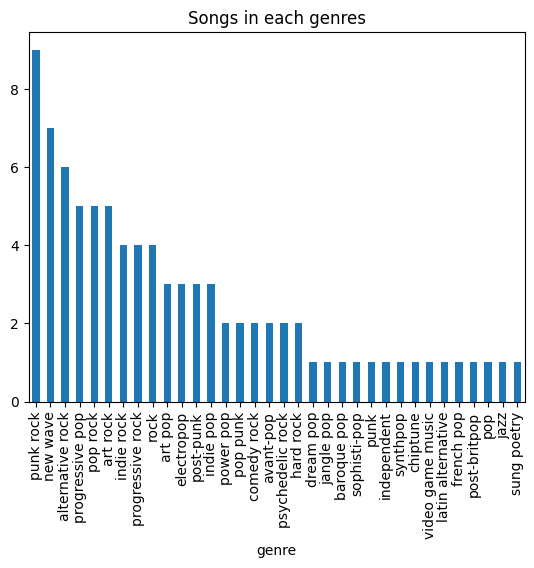

In [11]:
genres_df['genre'].value_counts().plot(kind='bar', title='Songs in each genres')

As we see some genres have the same words like art pop and art rock

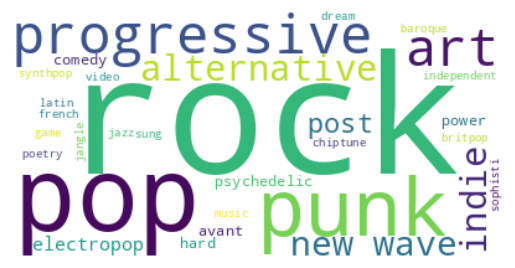

In [153]:
text = ' '.join(genres_df['genre'])
text.replace('-', ' ')
worcloud = WordCloud( background_color="white").generate(text)
plt.figure()
plt.imshow(worcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [13]:
track_artist_df = tracks_df.merge(albums_df, on='album_id').merge(album_artist_df, on='album_id').merge(artists_df, on='artist_id')

<Axes: title={'center': 'Songs by artists'}, xlabel='artist_name'>

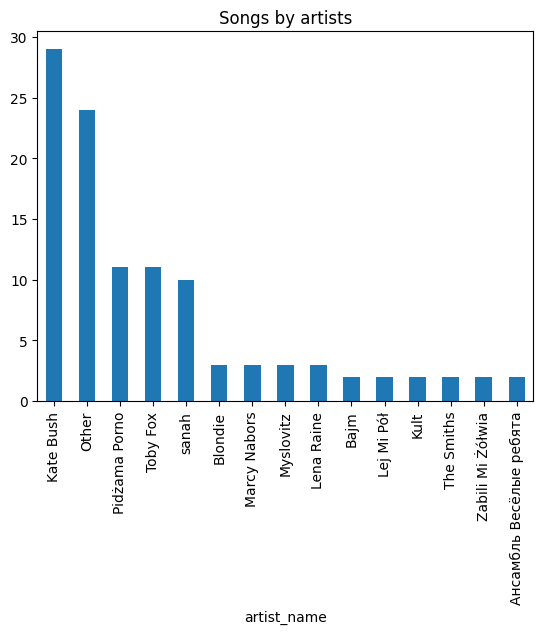

In [14]:
artist_tc_df = track_artist_df.groupby('artist_name')['track_id'].count()
artist_tc_df.loc['Other'] = artist_tc_df[artist_tc_df < 2].sum()
artist_tc_df = artist_tc_df[artist_tc_df >= 2]
artist_tc_df.sort_values(ascending=False).plot(kind='bar', title='Songs by artists', ylabel='')

<Axes: title={'center': 'Songs by albums'}>

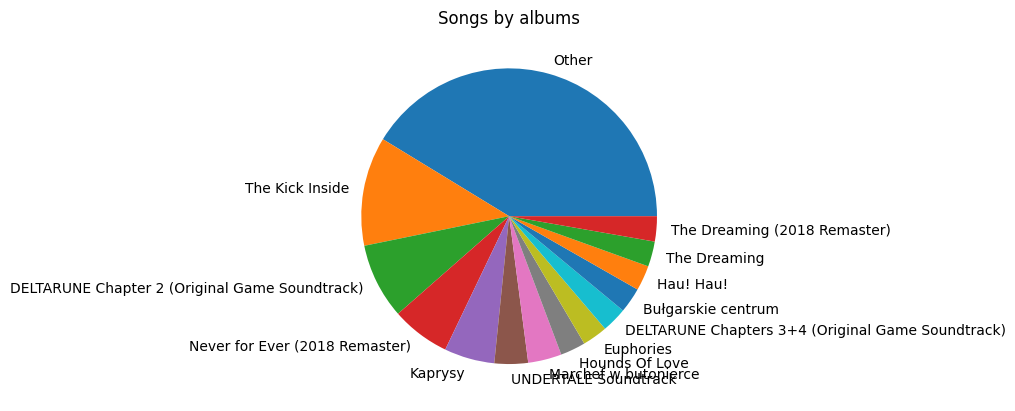

In [17]:
pie_df = track_artist_df.groupby('album_name')['track_id'].count()
pie_df.loc['Other'] = pie_df[pie_df < 3].sum()
pie_df = pie_df[pie_df >= 3]
pie_df.sort_values(ascending=False).plot(kind='pie', title='Songs by albums', ylabel='')

<Axes: title={'center': 'Release year distribution'}, xlabel='release_year'>

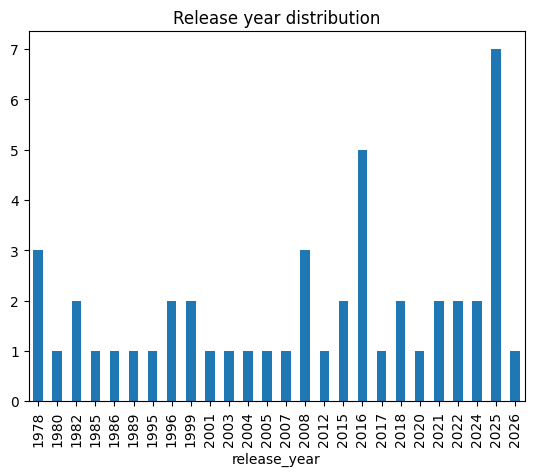

In [20]:
albums_df.groupby('release_year')['album_id'].count().plot(kind='bar', title='Release year distribution')

<Axes: title={'center': 'Release decade distribution'}, ylabel='album_id'>

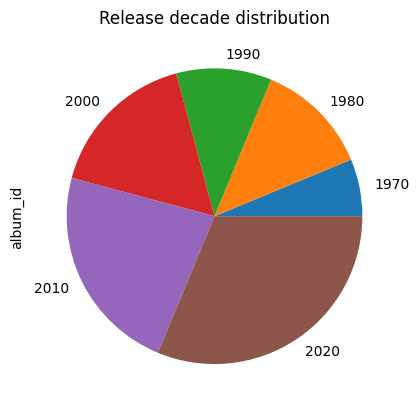

In [69]:
albums_df['decade'] = albums_df['release_year'] // 10 * 10
albums_df.groupby('decade')['album_id'].count().plot(kind='pie', title='Release decade distribution')

## Rankings

Let's look at the tops of the gathered rankings

In [161]:
short_t_ranking_df = tracks_short_df.merge(tracks_df, on='track_id')
short_t_ranking_df['track_name'].head(5)

,track_name
0,BIG SHOT
1,Jig Of Life
2,Delius - 2018 Remaster
3,Violin - 2018 Remaster
4,Moving


In [162]:
medium_t_ranking_df = tracks_medium_df.merge(tracks_df, on='track_id')
medium_t_ranking_df['track_name'].head(5)

,track_name
0,Night Of The Swallow
1,THE WORLD REVOLVING
2,Bigmouth Strikes Again - 2011 Remaster
3,Spear of Justice
4,ASGORE


In [163]:
long_t_ranking_df = tracks_long_df.merge(tracks_df, on='track_id')
long_t_ranking_df['track_name'].head(5)

,track_name
0,Peggy Brown
1,THE WORLD REVOLVING
2,Bigmouth Strikes Again - 2011 Remaster
3,Spear of Justice
4,ASGORE


In [164]:
short_a_ranking_df = artists_short_df.merge(artists_df, on='artist_id')
short_a_ranking_df['artist_name'].head(5)

,artist_name
0,Kate Bush
1,Toby Fox
2,Pidżama Porno
3,The Smiths
4,Blondie


In [165]:
medium_a_ranking_df = artists_medium_df.merge(artists_df, on='artist_id')
medium_a_ranking_df['artist_name'].head(5)

,artist_name
0,Kate Bush
1,Toby Fox
2,Pidżama Porno
3,Myslovitz
4,Blondie


In [166]:
long_a_ranking_df = artists_long_df.merge(artists_df, on='artist_id')
long_a_ranking_df['artist_name'].head(5)

,artist_name
0,sanah
1,Kate Bush
2,Toby Fox
3,Myslovitz
4,Pidżama Porno


Let's check how some artists places in rankings changed

Text(0.5, 1.0, 'Place through rankings')

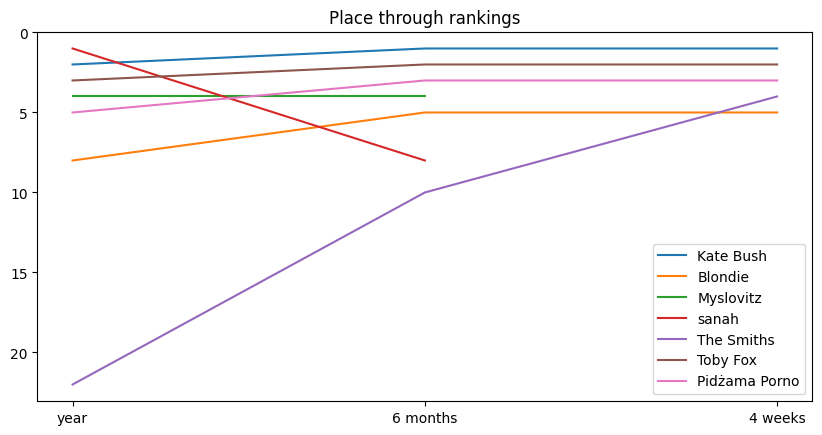

In [167]:
labels = []
places = []
ids = []
ids += artists_short_df['artist_id'].head(5).values.tolist()
ids += artists_medium_df['artist_id'].head(5).values.tolist()
ids += artists_long_df['artist_id'].head(5).values.tolist()
ids = set(ids)
for i in ids:
  label = artists_df[artists_df['artist_id'] == i]['artist_name'].values[0]
  if label not in labels:
    labels.append(label)
    if i in artists_short_df['artist_id'].values:
      short_place = artists_short_df[artists_short_df['artist_id'] == i]['place'].values[0] + 1
    else:
      short_place = None
    if i in artists_medium_df['artist_id'].values:
      medium_place = artists_medium_df[artists_medium_df['artist_id'] == i]['place'].values[0] + 1
    else:
      medium_place = None
    if i in artists_long_df['artist_id'].values:
      long_place = artists_long_df[artists_long_df['artist_id'] == i]['place'].values[0] + 1
    else:
      long_place = None
    places.append([long_place, medium_place, short_place])
f = plt.figure()
f.set_figwidth(10)
for i, label in enumerate(labels):
  plt.plot(['year', '6 months', '4 weeks'],places[i])
plt.gca().invert_yaxis()
plt.legend(labels)
plt.title('Place through rankings')

We need to remember that songs that I've listened to in the last 4 weeks also affect the last year ranking, so small increase in place between last 6 months ranking and last year ranking means that I've started listening the artist more

Text(0.5, 1.0, 'year')

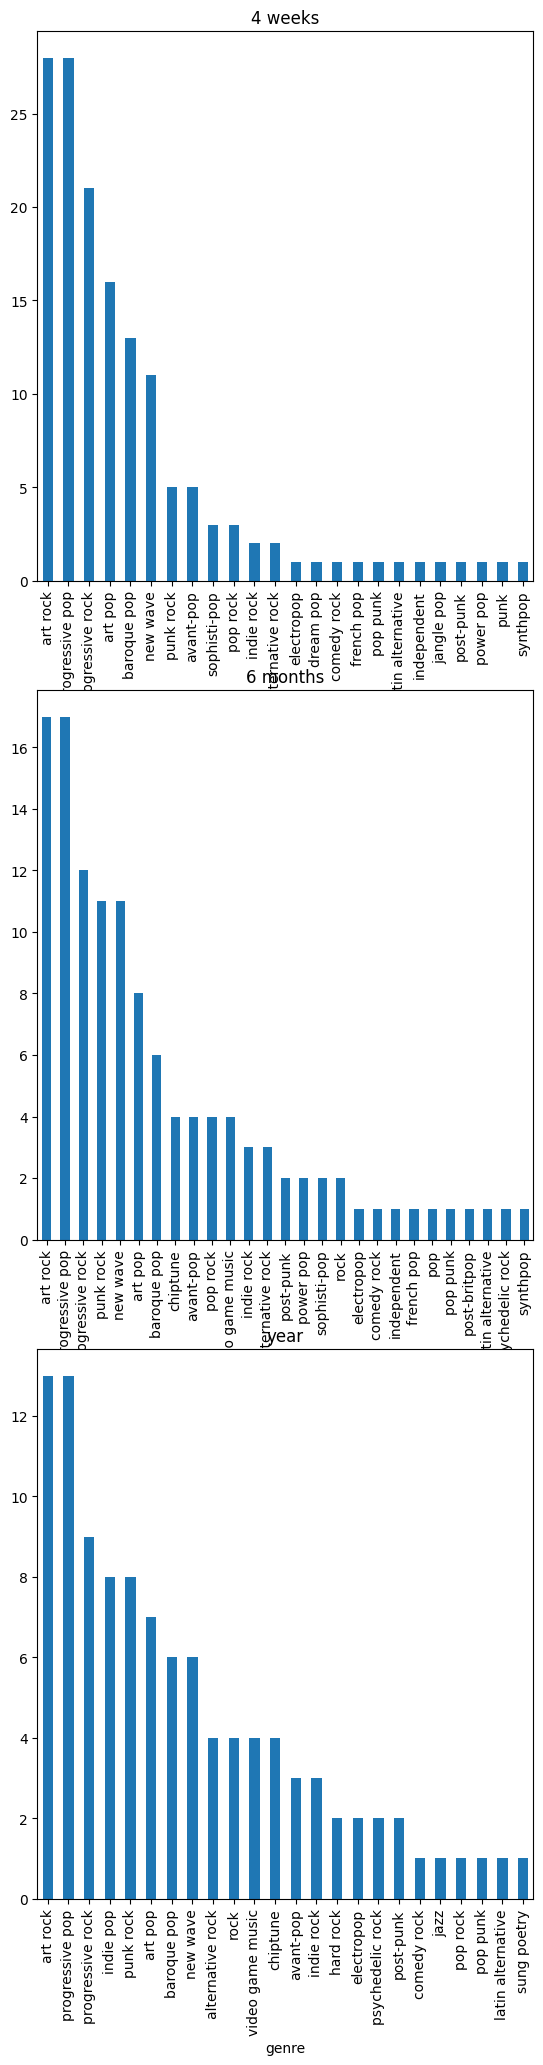

In [192]:
short_genre_ranking_df = short_t_ranking_df.merge(albums_df, on='album_id').merge(genres_df, on='album_id')
medium_genre_ranking_df = medium_t_ranking_df.merge(albums_df, on='album_id').merge(genres_df, on='album_id')
long_genre_ranking_df = long_t_ranking_df.merge(albums_df, on='album_id').merge(genres_df, on='album_id')
fig, ax = plt.subplots(3, 1)
fig.subplots_adjust(top = 4)
short_genre_ranking_df.groupby('genre')['track_id'].count().sort_values(ascending = False).plot(kind='bar', ax = ax[0])
medium_genre_ranking_df.groupby('genre')['track_id'].count().sort_values(ascending = False).plot(kind='bar', ax = ax[1])
long_genre_ranking_df.groupby('genre')['track_id'].count().sort_values(ascending = False).plot(kind='bar', ax = ax[2])
ax[0].set_title("4 weeks")
ax[1].set_title("6 months")
ax[2].set_title("year")

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

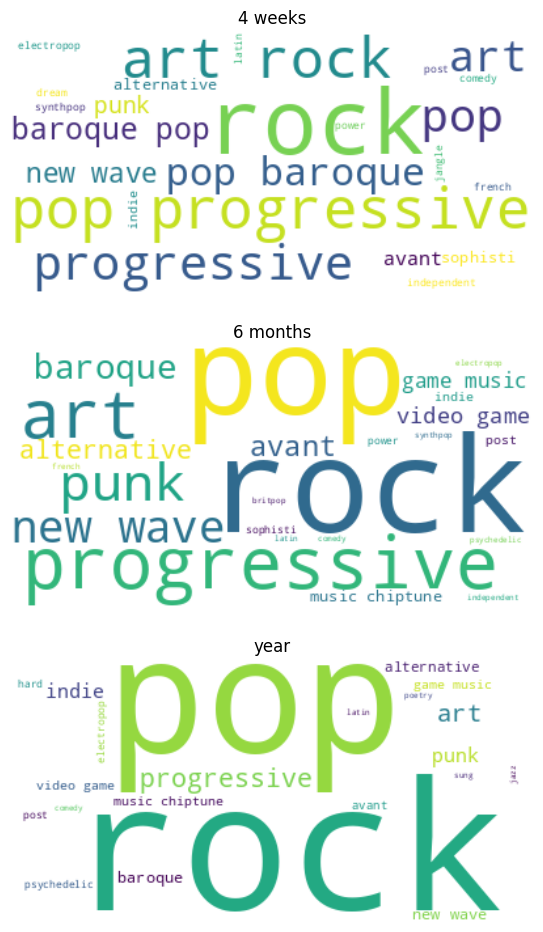

In [176]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1)
fig.set_figwidth(10)
fig.set_figheight(10)
fig.subplots_adjust(top=1)
text = ' '.join(short_genre_ranking_df['genre'])
text.replace('-', ' ')
worcloud = WordCloud( background_color="white").generate(text)
ax1.imshow(worcloud, interpolation="bilinear")
ax1.set_title('4 weeks')

text = ' '.join(medium_genre_ranking_df['genre'])
text.replace('-', ' ')
worcloud = WordCloud( background_color="white").generate(text)
ax2.imshow(worcloud, interpolation="bilinear")
ax2.set_title('6 months')

text = ' '.join(long_genre_ranking_df['genre'])
text.replace('-', ' ')
worcloud = WordCloud( background_color="white").generate(text)
ax3.imshow(worcloud, interpolation="bilinear")
ax3.set_title('year')

ax1.axis('off')
ax2.axis('off')
ax3.axis('off')

Text(0.5, 1.0, 'year')

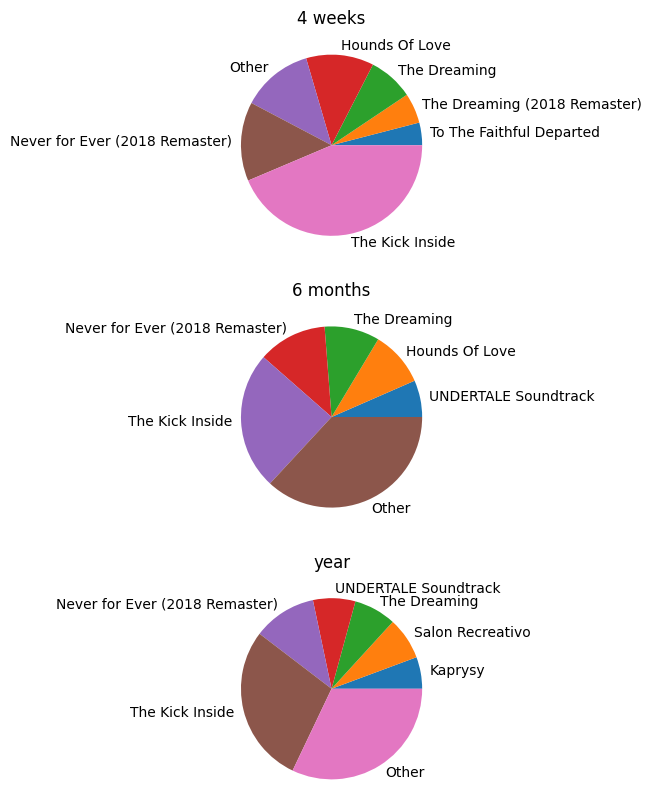

In [191]:
fig, (ax1, ax2, ax3) = plt.subplots(3,1)
fig.set_figheight(10)
short_album = short_genre_ranking_df.groupby('album_name')['track_id'].count()
medium_album = medium_genre_ranking_df.groupby('album_name')['track_id'].count()
long_album = long_genre_ranking_df.groupby('album_name')['track_id'].count()

short_album.loc['Other'] = short_album[short_album < 5].sum()
medium_album.loc['Other'] = medium_album[medium_album < 5].sum()
long_album.loc['Other'] = long_album[long_album < 5].sum()
short_album = short_album[short_album >= 5]
medium_album = medium_album[medium_album >= 5]
long_album = long_album[long_album >= 5]

short_album.sort_values().plot(kind = 'pie', ax = ax1, ylabel = '')
medium_album.sort_values().plot(kind = 'pie', ax = ax2, ylabel = '')
long_album.sort_values().plot(kind = 'pie', ax = ax3, ylabel = '')
ax1.set_title('4 weeks')
ax2.set_title('6 months')
ax3.set_title('year')

As we see, I've discovered more Kate Bush's albums recently...

Text(0.5, 1.0, 'year')

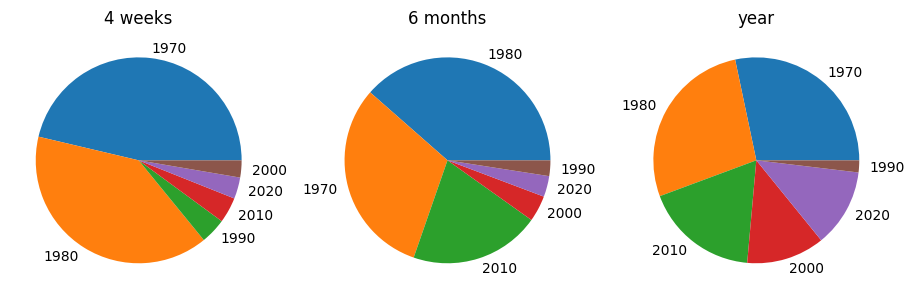

In [186]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(10)
fig.subplots_adjust(right = 1)
short_genre_ranking_df.groupby('decade')['track_id'].count().sort_values(ascending = False).plot(kind='pie', ax = ax1, ylabel='')
medium_genre_ranking_df.groupby('decade')['track_id'].count().sort_values(ascending = False).plot(kind='pie', ax = ax2, ylabel='')
long_genre_ranking_df.groupby('decade')['track_id'].count().sort_values(ascending = False).plot(kind='pie', ax = ax3, ylabel='')
ax1.set_title('4 weeks')
ax2.set_title('6 months')
ax3.set_title('year')

In [183]:
print(f"Avarage song release year from last 4 weeks: ", int(short_genre_ranking_df['release_year'].mean()))
print(f"Avarage song release year from last 6 months: ", int(medium_genre_ranking_df['release_year'].mean()))
print(f"Avarage song release year from last year: ", int(long_genre_ranking_df['release_year'].mean()))

Avarage song release year from last 4 weeks:  1984
Avarage song release year from last 6 months:  1990
Avarage song release year from last year:  1994


TODO:
- ranking analysis
  - show top 5 rankings
  - how artists places changed through rankings (line)
  - percentage of songs in a genre (column not pie) through 3 rankings
  - genres changing through rankings
  - release dates in three rankings
  - avarage ranking age
  - top albums by rankings
- some interpretations:
  - how my music taste changed
  - when i discovered and when i stopped listening to some artist
  - what category of songs would fit me today (without machine learning)

# Interpretation

- I listen to a lot of rock, punk, art pop etc
- I am a fan of Kate Bush
- Recently I listen more Kate Bush, Smiths, Blondie, Toby Fox and Pidzama Porno but I listen less Sanah and Myslovitz
- I listen more older music recently
- My music genres didn't change much through last year